# Assignment: Image Denoising using Autoencoder

## Objective
- Learn how to build and train an autoencoder.
- Understand how autoencoders can be used to remove noise from images.
- Evaluate the performance of the model on noisy images.

---

## Dataset
- Use **CIFAR-10** or MINST datasets.
- Add Gaussian noise to the images to simulate noisy input.

---

## Tasks

### 1. Data Preparation
- Load the dataset (e.g., MNIST or CIFAR-10).
- Normalize pixel values between 0 and 1.
- Add random Gaussian noise to the images.
- Split into training and testing sets.

### 2. Build Autoencoder
- Design a simple autoencoder architecture:
  - **Encoder:** Compress input to a latent representation.
  - **Decoder:** Reconstruct the image from the latent representation.
- Use fully connected layers or convolutional layers (CNN autoencoder recommended for image data).

### 3. Training
- Use **Mean Squared Error (MSE)** or **Binary Crossentropy** as the loss function.
- Train the autoencoder on noisy images with clean images as labels.

### 4. Evaluation
- Test the trained autoencoder on noisy test images.
- Visualize results:
  - Original clean image.
  - Noisy input image.
  - Denoised (reconstructed) output image.

### 5. Optional Enhancements
- Try different noise levels and analyze model robustness.
- Compare **Fully Connected Autoencoder vs. Convolutional Autoencoder**.
- Use **PSNR (Peak Signal-to-Noise Ratio)** or **SSIM (Structural Similarity Index)** to quantitatively measure denoising performance.

---

## Deliverables
- Python notebook with code.
- Visualizations showing denoising results.
- Short report (1-2 pages) describing:
  - Model architecture
  - Training process
  - Observations and performance metrics


In [1]:
!pip install -q tensorflow matplotlib numpy

## Solution1: Using Fully Connected Autoencoder

In [7]:
# Step1: Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

print("✓ Libraries imported successfully")

# Step2: Load CIFAR-10 dataset (60,000 color images of 10 different categories.
## Each image is of 32x32 pixels in 3 RGB channels)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)  # (50000, 32, 32, 3)
print(x_test.shape)   # (10000, 32, 32, 3)

✓ Libraries imported successfully
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [8]:
# Step3: Preprocessing the images
# Normalize images to [0, 1]
x_train_normalized = x_train.copy()
x_test_normalized = x_test.copy()
x_train_normalized = x_train_normalized.astype('float32') / 255.0
x_test_normalized = x_test_normalized.astype('float32') / 255.0

# Flatten images (flattening it to 1D for Dense/Fully Connected Network)
x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], -1)  # (50000, 3072). 3072 -> 32 x 32 x 3
x_test_flat = x_test_normalized.reshape(x_test_normalized.shape[0], -1)     # (10000, 3072)

print(x_train_flat.shape, x_test_flat.shape)
print(x_test_flat[0])


(50000, 3072) (10000, 3072)
[0.61960787 0.4392157  0.19215687 ... 0.08235294 0.2627451  0.43137255]


In [9]:
# Step4: Add Noise (Creating Noise Images)
## this is not necessary if you have noisy images already available
noise_factor = 0.2
x_train_noisy = x_train_flat + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_flat.shape)
x_test_noisy = x_test_flat + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_flat.shape)

# Clip to keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


In [10]:
# Step5: Build the Autoencoder Model
latency_space_dimension = 32
input_layer_shape = 32 * 32 * 3

## Input layer
input_layer = keras.Input(shape=(input_layer_shape,))

## Encoder Layer
encoded = layers.Dense(256, activation='relu')(input_layer)
encoded = layers.Dense(128, activation='relu')(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)

## Latent Layer
latent = layers.Dense(latency_space_dimension, activation='relu')(encoded)

## Decoder Layer
decoded = layers.Dense(64, activation='relu')(latent)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(256, activation='relu')(decoded)

# Output Layer
output_layer = layers.Dense(input_layer_shape, activation='sigmoid')(decoded)

autoencoder = keras.Model(inputs=input_layer, outputs=output_layer)

## Define the loss function and optimizer
autoencoder.compile(optimizer='adam', loss='mse')

print("✓ Autoencoder model built successfully")
print(f"Compression ratio: {3072}/{latency_space_dimension} = {3072/latency_space_dimension:.1f}x")
autoencoder.summary()

✓ Autoencoder model built successfully
Compression ratio: 3072/32 = 96.0x


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3072)           │       789,504 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,662,880 (6.34 MB)

 Trainable params: 1,662,880 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step6: Train the autoencoder
autoencoder.fit(x_train_noisy, x_train_flat,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test_flat))
print("✓ Training completed!")

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0514 - val_loss: 0.0325
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0291 - val_loss: 0.0267
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0259 - val_loss: 0.0242
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0243 - val_loss: 0.0236
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0230 - val_loss: 0.0225
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0222 - val_loss: 0.0215
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0213 - val_loss: 0.0212
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0207 - val_loss: 0.0202
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0204 - val_loss: 0.0197
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0195 - val_loss: 0.0192
✓ Training completed!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


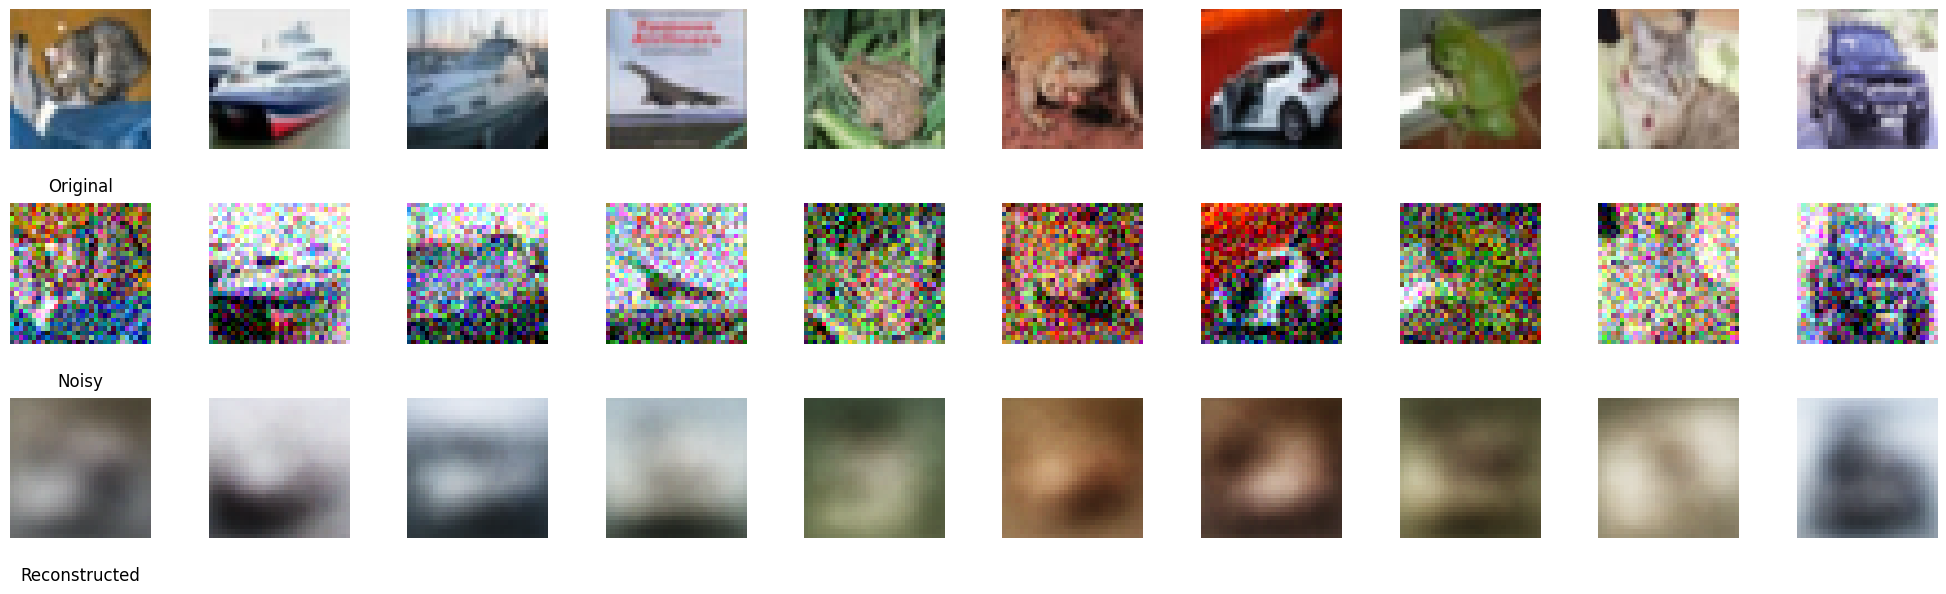

In [16]:
# Step7: Evaluate by Reconstructing 10 images from test dataset
import numpy as np
import matplotlib.pyplot as plt

num_samples = 10
noisy_images_subset = x_test_noisy[:num_samples]

# Predict using autoencoder
reconstructed_flat_images = autoencoder.predict(noisy_images_subset)

# Reshape to original image shape
reconstructed_images = reconstructed_flat_images.reshape(num_samples, 32, 32, 3)

# De-normalize
reconstructed_images_uint8 = np.clip(reconstructed_images * 255, 0, 255).astype('uint8')

# Original images
original_images = x_test[:num_samples]

# Reshape noisy images
noisy_images_reshaped = noisy_images_subset.reshape(num_samples, 32, 32, 3)

# Plot
fig, axes = plt.subplots(3, num_samples, figsize=(20, 6))

labels = ["Original", "Noisy", "Reconstructed"]

for row, images in enumerate([original_images, noisy_images_reshaped, reconstructed_images_uint8]):
    for col in range(num_samples):
        axes[row, col].imshow(images[col])
        axes[row, col].axis('off')
        # Add label below the first column only
        if col == 0:
            axes[row, col].text(0.5, -0.3, labels[row], transform=axes[row, col].transAxes,
                                ha='center', fontsize=12)

plt.tight_layout()
plt.show()



### Conclusion
You could see the reconstructed images are not looking right. This is because we are using "Fully Connected / Dense Network". Dense layers cannot capture spatial relationships like edges, textures, or local patterns.

## Solution2: Using Convolutional Autoencoder

In [23]:
# Step1: Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

print("✓ Libraries imported successfully")

# Step2: Load CIFAR-10 dataset (60,000 color images of 10 different categories.
## Each image is of 32x32 pixels in 3 RGB channels)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)  # (50000, 32, 32, 3)
print(x_test.shape)   # (10000, 32, 32, 3)

✓ Libraries imported successfully
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [24]:
# Step3: Preprocessing the images
# Normalize images to [0, 1]
x_train_normalized = x_train.copy()
x_test_normalized = x_test.copy()
x_train_normalized = x_train_normalized.astype('float32') / 255.0
x_test_normalized = x_test_normalized.astype('float32') / 255.0

print(x_train_normalized.shape, x_test_normalized.shape)
print(x_test_normalized[0])


(50000, 32, 32, 3) (10000, 32, 32, 3)
[[[0.61960787 0.4392157  0.19215687]
  [0.62352943 0.43529412 0.18431373]
  [0.64705884 0.45490196 0.2       ]
  ...
  [0.5372549  0.37254903 0.14117648]
  [0.49411765 0.35686275 0.14117648]
  [0.45490196 0.33333334 0.12941177]]

 [[0.59607846 0.4392157  0.2       ]
  [0.5921569  0.43137255 0.15686275]
  [0.62352943 0.44705883 0.1764706 ]
  ...
  [0.53333336 0.37254903 0.12156863]
  [0.49019608 0.35686275 0.1254902 ]
  [0.46666667 0.34509805 0.13333334]]

 [[0.5921569  0.43137255 0.18431373]
  [0.5921569  0.42745098 0.12941177]
  [0.61960787 0.43529412 0.14117648]
  ...
  [0.54509807 0.38431373 0.13333334]
  [0.50980395 0.37254903 0.13333334]
  [0.47058824 0.34901962 0.12941177]]

 ...

 [[0.26666668 0.4862745  0.69411767]
  [0.16470589 0.39215687 0.5803922 ]
  [0.12156863 0.34509805 0.5372549 ]
  ...
  [0.14901961 0.38039216 0.57254905]
  [0.05098039 0.2509804  0.42352942]
  [0.15686275 0.33333334 0.49803922]]

 [[0.23921569 0.45490196 0.65882355]

In [25]:
# Step4: Add Noise (Creating Noise Images)
## this is not necessary if you have noisy images already available
noise_factor = 0.2
x_train_noisy = x_train_normalized + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_normalized.shape)
x_test_noisy = x_test_normalized + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_normalized.shape)

# Clip to keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


In [36]:
# Step5: Build the Autoencoder Model
from tensorflow import keras
from tensorflow.keras import layers

# def ssim_loss(y_true, y_pred):
#     return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# Input Layer
input_layer = keras.Input(shape=(32,32,3)) # Input: 32x32 x3 channels

# Encoder
encoded = layers.Conv2D(32, 3, activation='relu', padding='same')(input_layer)
encoded = layers.MaxPooling2D(2, padding='same')(encoded) # Downsizing: Reduces the dimensions to 16x16
encoded = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
encoded = layers.MaxPooling2D(2, padding='same')(encoded) # Downsizing: Further reduces the dimensions to 8x8

# Latent Space: The compressed representation is 8x8x128 (Pixel size compressed from 32x32 to 8x8)
## this is called semantic compression though the actual vector size is bigger.
latent = layers.Conv2D(128, 3, activation='relu', padding='same')(encoded)

# Decoder
decoded = layers.Conv2D(128, 3, activation='relu', padding='same')(latent)
decoded = layers.UpSampling2D(2)(decoded) # Upsizing: Doubles the dimensions to 16x16
decoded = layers.Conv2D(64, 3, activation='relu', padding='same')(decoded)
decoded = layers.UpSampling2D(2)(decoded) # Upsizing: Doubles the dimensions back to 32x32
decoded = layers.Conv2D(32, 3, activation='relu', padding='same')(decoded)
output_layer = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(decoded)

autoencoder = keras.Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
# autoencoder.compile(optimizer='adam', loss=ssim_loss)

autoencoder.summary()

# Compression ratio
input_dim = 32*32*3  # 3072
latent_dim = 32
print(f"✓ Autoencoder model built successfully")
print(f"Compression ratio: {input_dim}/{latent_dim} = {input_dim/latent_dim:.2f}x")


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

✓ Autoencoder model built successfully
Compression ratio: 3072/32 = 96.00x


In [37]:
# Step6: Train the Encoder
autoencoder.fit(x_train_noisy, x_train_normalized,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test_normalized))


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - loss: 0.4607 - val_loss: 0.2875
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.2771 - val_loss: 0.2575
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.2516 - val_loss: 0.2476
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.2381 - val_loss: 0.2343
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.2276 - val_loss: 0.2214
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2209 - val_loss: 0.2208
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.2164 - val_loss: 0.2140
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2120 - val_loss: 0.2122
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2092 - val_loss: 0.2066
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.2075 - val_loss: 0.2054


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step


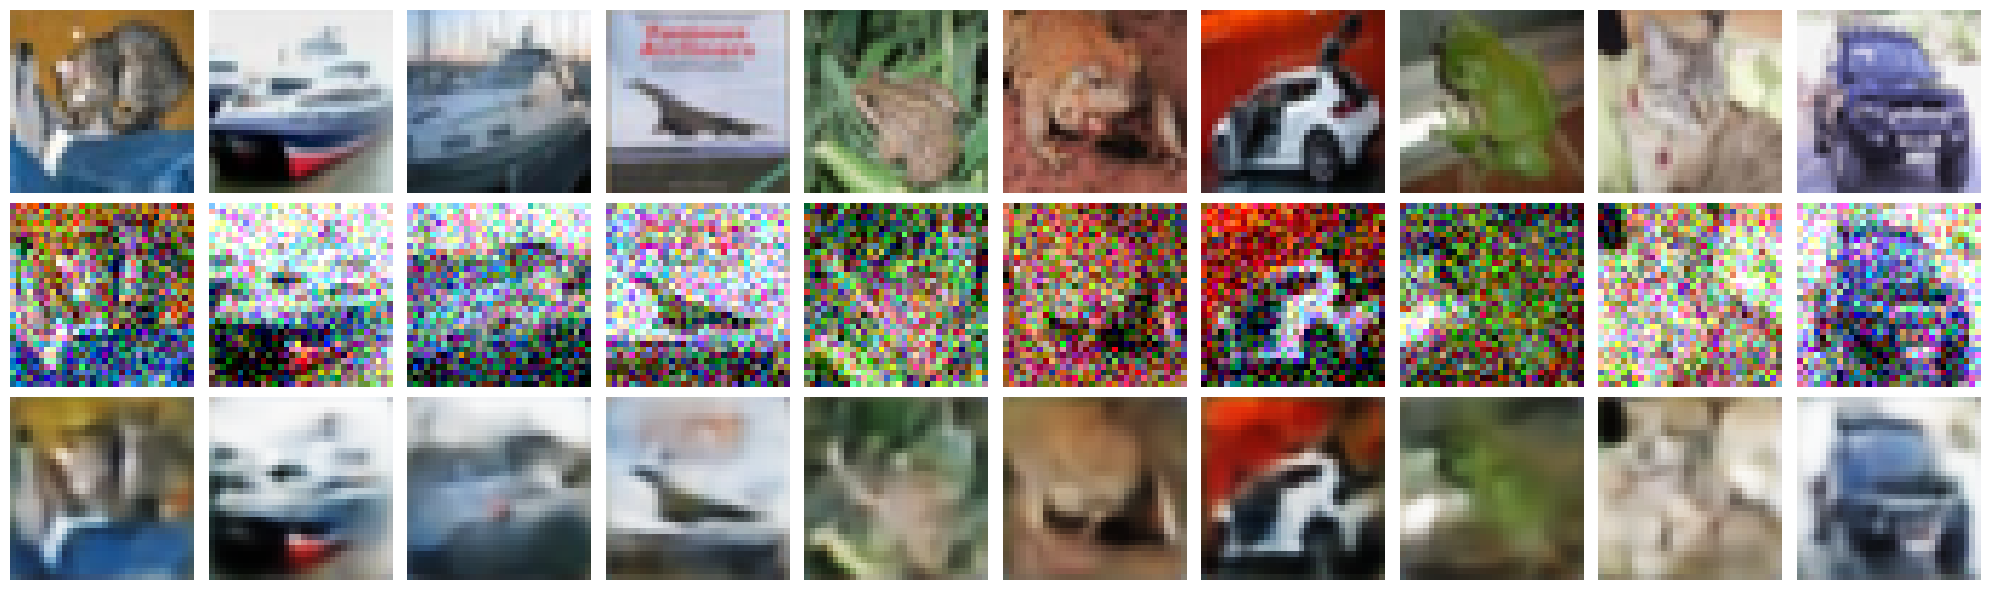

In [38]:
import numpy as np
import matplotlib.pyplot as plt

num_samples = 10
noisy_images_subset = x_test_noisy[:num_samples]  # shape: (num_samples, 32,32,3)

# Predict using autoencoder
reconstructed_images = autoencoder.predict(noisy_images_subset)  # already (num_samples,32,32,3)

# De-normalize to uint8 for visualization (optional)
reconstructed_images_uint8 = np.clip(reconstructed_images * 255, 0, 255).astype('uint8')
original_images_uint8 = x_test[:num_samples]
noisy_images_uint8 = np.clip(noisy_images_subset * 255, 0, 255).astype('uint8')

# Plot
fig, axes = plt.subplots(3, num_samples, figsize=(20, 6))
labels = ["Original", "Noisy", "Reconstructed"]

for row, images in enumerate([original_images_uint8, noisy_images_uint8, reconstructed_images_uint8]):
    for col in range(num_samples):
        axes[row, col].imshow(images[col])
        axes[row, col].axis('off')
        # Add label only for the first column
        if col == 0:
            axes[row, col].set_ylabel(labels[row], fontsize=12)

plt.tight_layout()
plt.show()


## Solution3: Using Fully Connected Autoencoder on MINST dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_16 (UpSampling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.2325 - val_loss: 0.1023
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1011 - val_loss: 0.0952
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0952 - val_loss: 0.0921
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0925 - val_loss: 0.0905
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0910 - val_loss: 0.0896
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0901 - val_loss: 0.0887
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0890 - val_loss: 0.0880
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0886 - val_loss: 0.0875
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0879 - val_loss: 0.0869
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0876 - val_loss: 0.0865


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


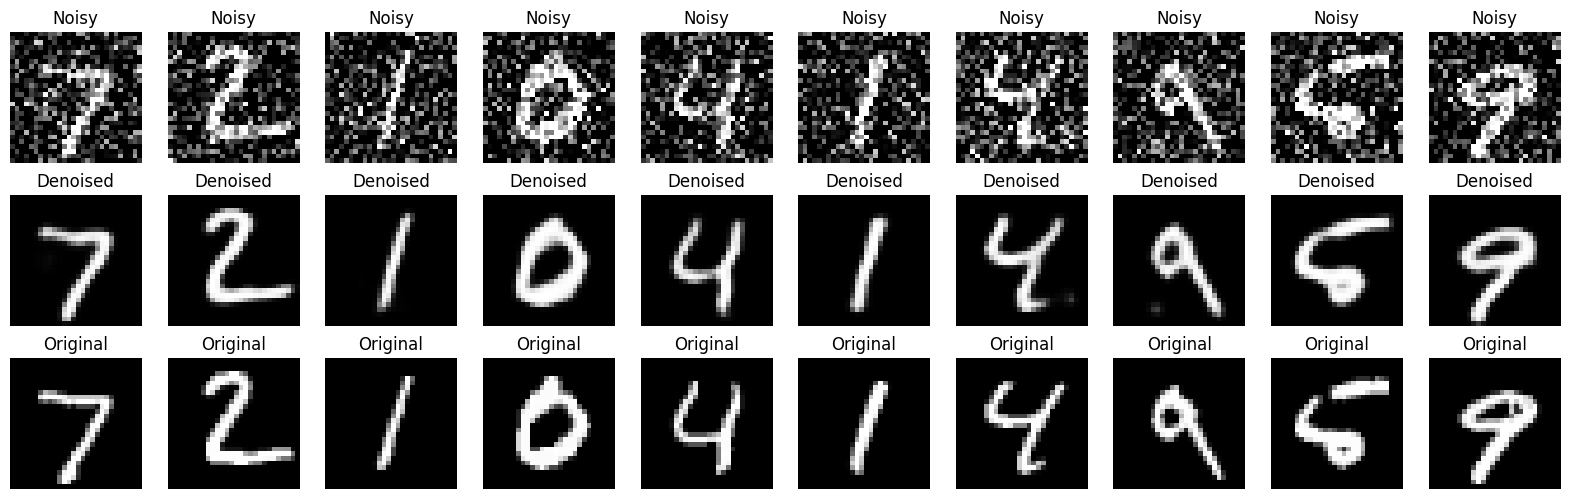

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

# ---------------------------
# 1️⃣ Load and normalize data
# ---------------------------
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Add a channel dimension: (28, 28) → (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# ---------------------------
# 2️⃣ Add random noise
# ---------------------------
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip to keep values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ---------------------------
# 3️⃣ Build the Autoencoder
# ---------------------------
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(1e-3), loss='binary_crossentropy')

autoencoder.summary()

# ---------------------------
# 4️⃣ Train the Autoencoder
# ---------------------------
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# ---------------------------
# 5️⃣ Test with a new noisy image
# ---------------------------
decoded_imgs = autoencoder.predict(x_test_noisy)

# ---------------------------
# 6️⃣ Visualize results
# ---------------------------
n = 10  # how many digits we will display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original + noise
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Display denoised image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # Display original clean image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")
plt.show()
